# BERT for Sentiment Analysis

## 1. Setup

In [14]:
!pip install -q transformers datasets wandb scikit-learn accelerate tabulate

In [15]:
import os
import gc
import time
import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import wandb

from config import SEED, NUM_LABELS, WANDB_PROJECT, REPORT_TO
from data_pipeline import set_seed, load_and_split, prepare_transformer_dataset

In [18]:
# Reproducibility
set_seed(SEED)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.mem_get_info(0)[1] / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
VRAM: 11.3 GB


In [19]:
# wandb login
os.environ.pop("WANDB_API_KEY", None)
wandb.login(relogin=True)
os.environ["WANDB_PROJECT"] = WANDB_PROJECT

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## 2. Model & Tokenizer

In [20]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## 3. Metrics & Training Function

In [21]:
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, F1 for evaluation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [22]:
def train_and_evaluate(subset_size=None, filepath=None, num_epochs=3,
                       batch_size=16, learning_rate=2e-5, run_name="bert"):
    """Train BERT and evaluate on test set"""

    # Load and tokenize data
    print(f"Loading data (subset_size={subset_size}, filepath={filepath})...")
    splits = load_and_split(subset_size=subset_size, filepath=filepath)
    print(f"  Train: {len(splits['train']['texts'])}, "
          f"Val: {len(splits['val']['texts'])}, "
          f"Test: {len(splits['test']['texts'])}")

    print("Tokenizing...")
    train_ds = prepare_transformer_dataset(
        splits["train"]["texts"], splits["train"]["labels"], MODEL_NAME
    )
    val_ds = prepare_transformer_dataset(
        splits["val"]["texts"], splits["val"]["labels"], MODEL_NAME
    )
    test_ds = prepare_transformer_dataset(
        splits["test"]["texts"], splits["test"]["labels"], MODEL_NAME
    )

    # Free raw text from memory
    del splits
    gc.collect()

    # Load fresh model for each run
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )

    # Calculate warmup steps (10% of total training steps)
    total_steps = (len(train_ds) // batch_size // 2) * num_epochs
    warmup_steps = int(total_steps * 0.1)

    # Training arguments
    args = TrainingArguments(
        output_dir=f"./results/{run_name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        gradient_accumulation_steps=2,           
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_steps=warmup_steps,
        fp16=True,                               
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        report_to=REPORT_TO,
        run_name=run_name,
        seed=SEED,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    # Train
    print(f"Training ({num_epochs} epochs, warmup={warmup_steps} steps)...")
    start_time = time.time()
    trainer.train()
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.1f}s")

    # Save log history for plotting
    log_history = trainer.state.log_history

    # Evaluate on test set using predict
    print("Evaluating on test set...")
    test_output = trainer.predict(test_ds)
    test_results = test_output.metrics
    test_results["training_time_seconds"] = training_time
    test_results["subset_size"] = subset_size
    test_results["filepath"] = filepath
    test_results["num_epochs"] = num_epochs
    test_results["log_history"] = log_history

    # Print results
    print(f"\n--- Results ({run_name}) ---")
    print(f"Accuracy:  {test_results['test_accuracy']:.4f}")
    print(f"Precision: {test_results['test_precision']:.4f}")
    print(f"Recall:    {test_results['test_recall']:.4f}")
    print(f"F1:        {test_results['test_f1']:.4f}")
    print(f"Time:      {training_time:.1f}s")

    # Cleanup GPU memory
    wandb.finish()
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

    return test_results

## 4. Training

In [24]:
# Run 1: 1K given dataset — baseline comparison
results_1k = train_and_evaluate(
    filepath="data/amazon_cells_labelled.txt",
    num_epochs=5,
    run_name="bert_1k",
)

Loading data (subset_size=None, filepath=data/amazon_cells_labelled.txt)...
  Train: 800, Val: 100, Test: 100
Tokenizing...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5833.20it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Training (5 epochs, warmup=12 steps)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.399266,0.910000,0.918367,0.900000,0.909091
2,0.859077,0.188391,0.930000,0.938776,0.920000,0.929293
3,0.859077,0.188122,0.920000,0.920000,0.920000,0.920000
4,0.162702,0.174509,0.930000,0.921569,0.940000,0.930693
5,0.162702,0.170098,0.950000,0.924528,0.980000,0.951456


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.68it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training completed in 27.7s
Evaluating on test set...



--- Results (bert_1k) ---
Accuracy:  0.9000
Precision: 0.9000
Recall:    0.9000
F1:        0.9000
Time:      27.7s


eval/accuracy,▁▅▃▅█
eval/f1,▁▄▃▅█
eval/loss,█▂▂▁▁
eval/precision,▁█▂▂▃
eval/recall,▁▃▃▅█
eval/runtime,▁▂▃█▁
eval/samples_per_second,█▆▅▁█
eval/steps_per_second,█▆▅▁█
test/accuracy,▁
test/f1,▁
+11,...


In [9]:
results_full = train_and_evaluate(
    subset_size=None,
    num_epochs=3,
    run_name="bert_full",
)


Loading data (subset_size=None, filepath=None)...
  Train: 2880000, Val: 360000, Test: 360000
Tokenizing...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5377.87it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Training (3 epochs, warmup=27000 steps)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.212489,0.111464,0.962439,0.964151,0.960594,0.962369
2,0.144935,0.110992,0.965219,0.964242,0.966272,0.965256
3,0.103727,0.122908,0.966131,0.967432,0.964739,0.966083


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.54it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training completed in 61292.2s
Evaluating on test set...



--- Results (bert_full) ---
Accuracy:  0.9659
Precision: 0.9654
Recall:    0.9664
F1:        0.9659
Time:      61292.2s


eval/accuracy,▁▆█
eval/f1,▁▆█
eval/loss,▁▁█
eval/precision,▁▁█
eval/recall,▁█▆
eval/runtime,▁▃█
eval/samples_per_second,█▆▁
eval/steps_per_second,█▆▁
test/accuracy,▁
test/f1,▁
+11,...


## 5. Results Summary

In [10]:
import pandas as pd

all_results = [results_1k, results_full]
exp_labels = ["1K / 5 epochs", "Full 3.6M / 3 epochs"]
summary = pd.DataFrame([
    {
        "Experiment": exp_labels[i],
        "Accuracy": round(r["test_accuracy"], 4),
        "Precision": round(r["test_precision"], 4),
        "Recall": round(r["test_recall"], 4),
        "F1": round(r["test_f1"], 4),
        "Time (s)": round(r["training_time_seconds"], 1),
    }
    for i, r in enumerate(all_results)
])
print(summary.to_markdown(index=False))

| Experiment           |   Accuracy |   Precision |   Recall |     F1 |   Time (s) |
|:---------------------|-----------:|------------:|---------:|-------:|-----------:|
| 1K / 5 epochs        |     0.91   |      0.9184 |   0.9    | 0.9091 |       23.3 |
| Full 3.6M / 3 epochs |     0.9659 |      0.9654 |   0.9664 | 0.9659 |    61292.2 |


## 6. Plots

In [11]:
import matplotlib.pyplot as plt

def extract_metrics(log_history):
    """Extract per-epoch train loss, val loss, and eval metrics from log history."""
    train_losses = []
    val_losses = []
    eval_acc = []
    eval_f1 = []
    epochs = []

    for entry in log_history:
        if "eval_loss" in entry:
            val_losses.append(entry["eval_loss"])
            eval_acc.append(entry.get("eval_accuracy", None))
            eval_f1.append(entry.get("eval_f1", None))
            epochs.append(entry["epoch"])
        if "loss" in entry and "eval_loss" not in entry:
            train_losses.append(entry["loss"])

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "eval_acc": eval_acc,
        "eval_f1": eval_f1,
        "epochs": epochs,
    }

### 6.1 Training & Validation Loss per Epoch

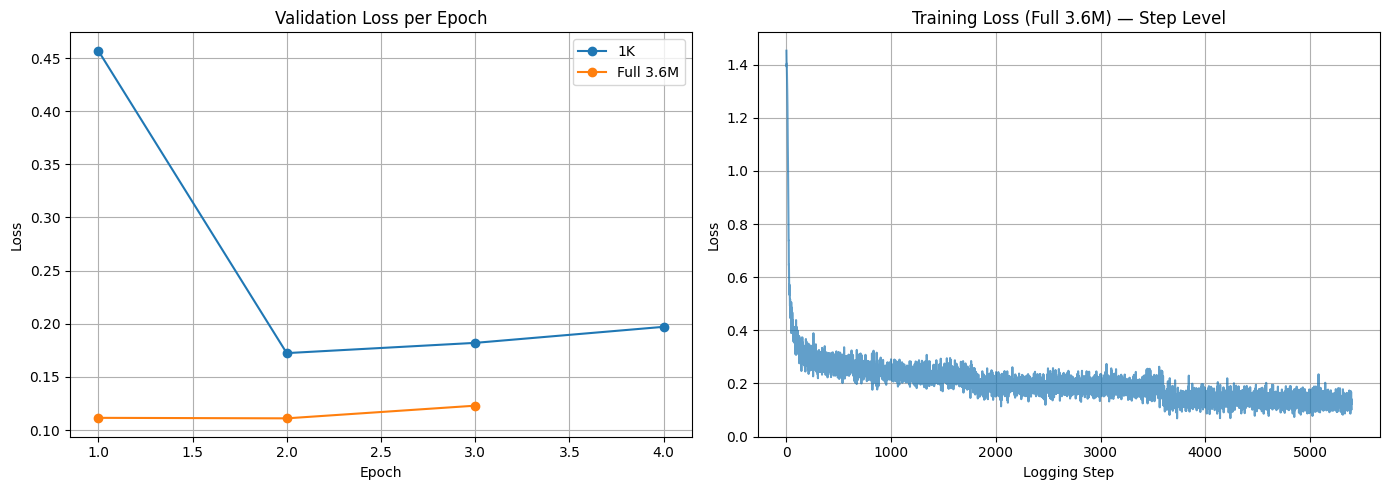

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for results, label in [(results_1k, "1K"), (results_full, "Full 3.6M")]:
    m = extract_metrics(results["log_history"])

    # Validation loss per epoch
    axes[0].plot(m["epochs"], m["val_losses"], marker="o", label=label)

axes[0].set_title("Validation Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Training loss (step-level) for full dataset
m_full = extract_metrics(results_full["log_history"])
axes[1].plot(m_full["train_losses"], alpha=0.7)
axes[1].set_title("Training Loss (Full 3.6M) — Step Level")
axes[1].set_xlabel("Logging Step")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/loss_curves.png", dpi=150)
plt.show()

### 6.2 Validation Accuracy & F1 per Epoch

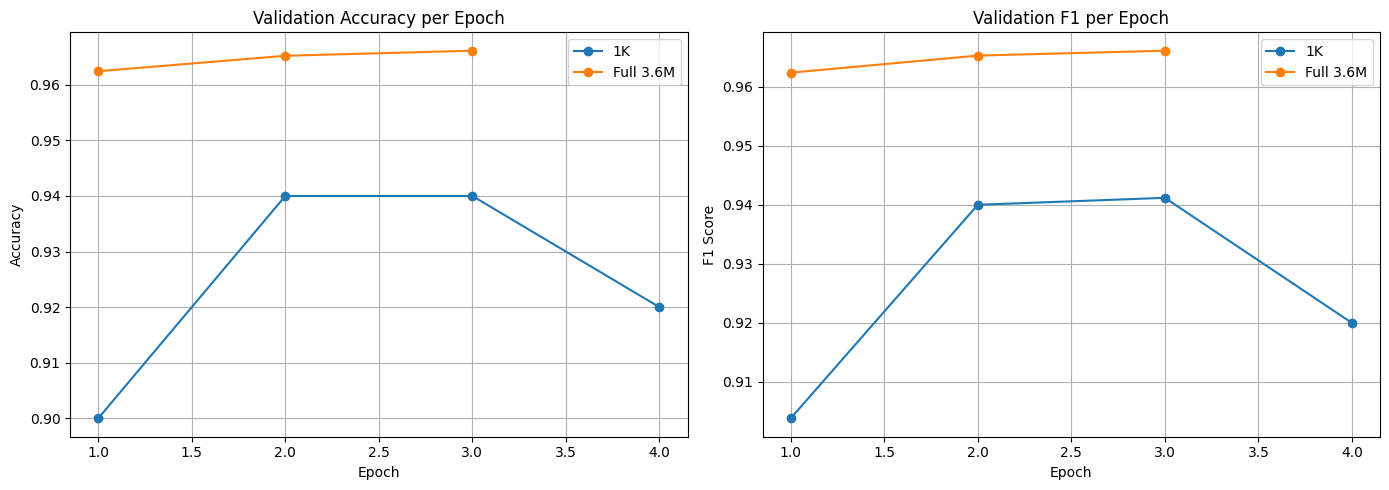

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for results, label in [(results_1k, "1K"), (results_full, "Full 3.6M")]:
    m = extract_metrics(results["log_history"])

    axes[0].plot(m["epochs"], m["eval_acc"], marker="o", label=label)
    axes[1].plot(m["epochs"], m["eval_f1"], marker="o", label=label)

axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Validation F1 per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/accuracy_f1_curves.png", dpi=150)
plt.show()

## 7. Analysis & Conclusions

### Convergence
- **1K dataset:** Training loss dropped from 0.859 (first log, epoch 2) to 0.163 (epoch 4), showing the model learned from the data. Validation loss decreased steadily across all 5 epochs: 0.399 → 0.188 → 0.188 → 0.175 → 0.170. No early stopping was triggered since validation loss kept improving. The best model was selected at epoch 5 (lowest validation loss 0.170).
- **3.6M dataset:** Training loss decreased steadily from 0.212 (epoch 1) → 0.145 (epoch 2) → 0.104 (epoch 3), indicating the model was still improving. Validation loss reached its minimum at epoch 2 (0.111), then increased at epoch 3 (0.123). The best model was selected at epoch 2.

### Overfitting
- **1K dataset:** Validation accuracy peaked at 95% (epoch 5), but test accuracy was only 90.0% — a 5% gap. This shows the model overfit to the tiny validation set (100 samples). With only 800 training samples and 100 validation samples, random variation is high and the model cannot generalize robustly.
- **3.6M dataset:** Validation loss increased from 0.111 (epoch 2) to 0.123 (epoch 3), an 11% increase, while training loss continued to decrease (0.145 → 0.104). This is a mild sign of overfitting. However, validation accuracy remained high (96.5–96.6%) and test accuracy (96.59%) closely matched validation accuracy, confirming the model generalizes well at scale.

### Data Scaling Impact
- Increasing data from 1K to 3.6M improved test accuracy from 90.0% to 96.59% (+6.59%) and test F1 from 90.0% to 96.59% (+6.59%).
- The 3.6M model achieves balanced precision (96.54%) and recall (96.64%). The 1K model shows equal precision and recall (both 90.0%), but with only 100 test samples, these numbers are subject to high variance.
- Even with fewer epochs (3 vs 5), the larger dataset produces a significantly better model. This confirms that for pre-trained transformers, data quantity matters more than training duration.

### Learning Rate Schedule
- We used linear warmup (10% of total steps: 12 warmup steps for 1K, 27,000 for 3.6M) followed by linear decay. Warmup prevents gradient instability in early training when the new classification head has random weights; decay gradually reduces the learning rate as the model fine-tunes.

### Best Model Selection
- `load_best_model_at_end=True` with `metric_for_best_model="eval_loss"` and `greater_is_better=False` ensures we always load the checkpoint with the lowest validation loss. For the 1K run this was epoch 5 (val loss 0.170); for the 3.6M run this was epoch 2 (val loss 0.111).
- `EarlyStoppingCallback(patience=2)` was configured but did not trigger for the 1K run (validation loss kept improving). For the 3.6M run, it would require epoch 4 to trigger (only 3 epochs were run).